In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav_df = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"]
)

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav_df['daily_return'] = nav_df.groupby(
    'amfi_code'
)['nav'].pct_change()

In [5]:
nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav_df.isna().sum()

amfi_code        0
date             0
nav              0
daily_return    40
dtype: int64

In [7]:
# validate return distribution
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

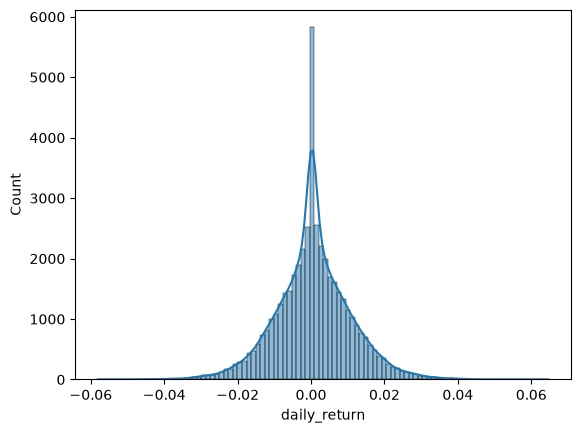

In [8]:
import seaborn as sns

fig = sns.histplot(
    data=nav_df,
    x='daily_return',
    bins=100,
    kde=True
)


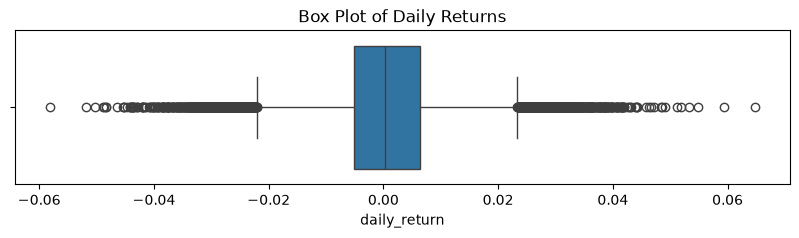

In [9]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav_df["daily_return"].dropna()
)

plt.title("Box Plot of Daily Returns")

plt.show()

In [10]:
# finding largest gains and losses
nav_df.nlargest(10, 'daily_return')[['amfi_code', 'date', 'daily_return']]

,amfi_code,date,daily_return
24745,119598,2024-04-15,0.064713
13226,118634,2024-03-19,0.059304
5207,101207,2024-05-01,0.054851
25566,119599,2023-01-10,0.053320
25832,119599,2024-01-17,0.051811
24155,119598,2022-01-10,0.051113
24371,119598,2022-11-08,0.049051
45082,149324,2022-11-23,0.048490
24356,119598,2022-10-18,0.048454
25091,119598,2025-08-12,0.047123


In [11]:
nav_df.nsmallest(10, 'daily_return')[['amfi_code', 'date', 'daily_return']]

,amfi_code,date,daily_return
12774,118634,2022-06-24,-0.058102
4917,101207,2023-03-22,-0.051847
12952,118634,2023-03-01,-0.050335
45312,149324,2023-10-11,-0.048870
5560,101207,2025-09-08,-0.048634
19804,119095,2022-12-23,-0.048367
13333,118634,2024-08-15,-0.048305
20307,119095,2024-11-27,-0.046524
26048,119599,2024-11-14,-0.045429
38520,125498,2024-03-11,-0.045218


In [12]:
# Daily return validation indicates that the return distribution is centered around zero with a small number of positive and negative outliers. The observed range (approximately -5.8% to +6.5%) is consistent with expected equity mutual fund behavior, suggesting the dataset is suitable for further performance analysis.

In [13]:
# CAGR

cagr_df = nav_df.groupby('amfi_code').agg(
    start_nav = ('nav', 'first'),
    end_nav = ('nav', 'last'),
    start_date = ('date', 'first'),
    end_date = ('date', 'last')
).reset_index('amfi_code')

cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date
0,100016,520.4608,583.6113,2022-01-03,2026-05-29
1,100025,26.3169,31.8843,2022-01-03,2026-05-29
2,100033,107.3758,342.0072,2022-01-03,2026-05-29
3,101206,305.0996,773.2939,2022-01-03,2026-05-29
4,101207,38.5736,53.9836,2022-01-03,2026-05-29


In [14]:
#calculate investment years
cagr_df['years'] = (cagr_df['end_date'] - cagr_df['start_date']).dt.days / 365.25

In [15]:
cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726


In [16]:
cagr_df['CAGR'] = (cagr_df['end_nav'] / cagr_df['start_nav']) ** (1/cagr_df['years']) - 1   

In [17]:
cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388


In [18]:
cagr_df['pct_change'] = cagr_df['CAGR'] * 100
cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,pct_change
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371,2.637074
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582,4.458210
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232,30.123153
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384,23.538361
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388,7.938765


In [19]:
cagr_df[["amfi_code", "pct_change"]].head()

,amfi_code,pct_change
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [20]:
cagr_df = cagr_df.reset_index().sort_values(by='pct_change', ascending=False)

In [21]:
cagr_df.head()

,index,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,pct_change
25,25,120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,0.328274,32.827406
21,21,119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,0.324235,32.423536
39,39,149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,0.322874,32.287440
36,36,148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,0.319495,31.949523
34,34,148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,0.309741,30.974108


In [22]:
cagr_df[["amfi_code", "pct_change"]].head(10)

,amfi_code,pct_change
25,120505,32.827406
21,119598,32.423536
39,149324,32.287440
36,148569,31.949523
34,148567,30.974108
30,120843,30.907455
2,100033,30.123153
38,149323,29.581087
16,119094,28.214417
19,119551,25.804686


In [24]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [25]:
cagr_df.head()

,index,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR,pct_change,scheme_name
0,25,120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,0.328274,32.827406,ICICI Pru Midcap Fund - Regular - Growth
1,21,119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,0.324235,32.423536,SBI Small Cap Fund - Regular Plan - Growth
2,39,149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,0.322874,32.287440,DSP Small Cap Fund - Regular - Growth
3,36,148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,0.319495,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth
4,34,148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,0.309741,30.974108,Mirae Asset Large Cap Fund - Regular - Growth


In [26]:
cagr_df[['amfi_code','scheme_name','pct_change']].head()

,amfi_code,scheme_name,pct_change
0,120505,ICICI Pru Midcap Fund - Regular - Growth,32.827406
1,119598,SBI Small Cap Fund - Regular Plan - Growth,32.423536
2,149324,DSP Small Cap Fund - Regular - Growth,32.287440
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,31.949523
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,30.974108


In [27]:
import plotly.express as px
top_10 = cagr_df.head(10)

fig = px.bar(
    top_10,
    x='scheme_name',
    y='pct_change',
    title='Top 10 Mutual Funds by CAGR',
    labels={'pct_change': 'CAGR (%)', 'scheme_name': 'Mutual Fund Scheme'},
    color='pct_change')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [28]:
# maximum drawdown 

# running maximum NAV for each fund
nav_df['running_max'] = nav_df.groupby('amfi_code')['nav'].cummax()
nav_df.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [29]:
# drawdown calculation
nav_df['drawdown'] = (nav_df['nav'] / nav_df['running_max']) -1

In [30]:
nav_df['percent_drawdown'] = nav_df['drawdown'] * 100

In [31]:
nav_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,percent_drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306,-1.030568
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377,-1.137747
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574,-1.257370


In [32]:
# maximum drawdown
mdd_df = nav_df.groupby('amfi_code').agg(
    max_drawdown = ('percent_drawdown', 'min')
).sort_values(by='max_drawdown', ascending=False).reset_index()

In [33]:
mdd_df.head()

,amfi_code,max_drawdown
0,120507,-0.097731
1,120844,-0.116293
2,101208,-0.162250
3,100025,-4.308264
4,119120,-4.328729


In [34]:
nav_df["drawdown"].describe()

count    46000.000000
mean        -0.056068
std          0.071665
min         -0.525742
25%         -0.077660
50%         -0.033413
75%         -0.006930
max          0.000000
Name: drawdown, dtype: float64

In [35]:
# sharpe ratio
# Use Rf = 6.5%
# Since we have daily returns, we first convert the annual risk-free rate to a daily rate.

risk_free_rate = 0.065/252 # trading days

#Calculate Mean Daily Return

mean_return = (
    nav_df.groupby('amfi_code')['daily_return'].mean() 
)

mean_return.head()

amfi_code
100016    0.000142
100025    0.000170
100033    0.001080
101206    0.000852
101207    0.000424
Name: daily_return, dtype: float64

In [36]:
# Calculate Daily Volatility
volatility = (
    nav_df.groupby('amfi_code')['daily_return'].std()
)

In [38]:
# Calculate Sharpe Ratio
sharpe_df = pd.DataFrame({
    'mean_return': mean_return,
    'volatility': volatility
})
sharpe_df['sharpe_ratio'] = ((sharpe_df['mean_return'] - risk_free_rate) / sharpe_df['volatility']) * (252 ** 0.5)

# The standard way to annualize a Sharpe Ratio is: ------>



In [39]:
sharpe_df = sharpe_df.reset_index().sort_values(by='sharpe_ratio', ascending=False)

In [40]:
sharpe_df.head(10)

,amfi_code,mean_return,volatility,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


In [41]:
sharpe_df = sharpe_df.reset_index()

sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [42]:
sharpe_df = sharpe_df.reset_index().sort_values(by='sharpe_ratio', ascending=False)

In [43]:
sharpe_df.head(10)

,level_0,index,amfi_code,mean_return,volatility,sharpe_ratio,scheme_name
0,0,34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
1,1,30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
2,2,36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
3,3,19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
4,4,25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
5,5,38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
6,6,2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,7,9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
8,8,3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
9,9,24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [44]:
# higher ratio = better 

In [45]:
# Sortino says:
#"I don't mind big positive returns. Only negative returns are risky

#We'll do it in four simple steps:

#Create a dataframe containing only negative daily returns.
#Compute downside deviation for each fund.
#Reuse the mean return from Sharpe.
#Calculate the Sortino Ratio and rank all funds.

#The Sharpe Ratio uses all daily returns to calculate risk.
#The Sortino Ratio only considers negative daily returns.



In [ ]:
# creating downside return column
nav_df['downside_return'] = nav_df['daily_return'].clip(upper=0) #Positive returns become 0, while negative returns remain unchanged.

In [48]:
# Calculate Downside Deviation
downside_std = (
    nav_df.groupby('amfi_code')['downside_return'].std()  
)

In [49]:
sortino_df = pd.DataFrame({
    "mean_return": mean_return,
    "downside_std": downside_std
})

In [51]:
# sortino ratio 
risk_free_daily = 0.065 / 252  # Annual risk-free rate converted to daily
sortino_df["sortino_ratio"] = (
    (sortino_df["mean_return"] - risk_free_daily)
    / sortino_df["downside_std"]
) * (252 ** 0.5)

In [52]:
sortino_df = sortino_df.reset_index()

sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [53]:
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_df[
    ["scheme_name", "sortino_ratio"]
].head(10)

,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.609850
30,Kotak Flexicap Fund - Regular - Growth,2.463887
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.278106
19,SBI Bluechip Fund - Regular Plan - Growth,2.243325
25,ICICI Pru Midcap Fund - Regular - Growth,2.158384
38,DSP Midcap Fund - Regular - Growth,2.011887
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.967316
9,Nippon India Large Cap Fund - Regular - Growth,1.961986
3,ABSL Frontline Equity Fund - Regular - Growth,1.889576
24,ICICI Pru Bluechip Fund - Direct - Growth,1.877411


In [54]:
# alpha and beta

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [55]:
benchmark_df.head()


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [56]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [57]:
benchmark_df["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [58]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

In [59]:
market_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [60]:
# calculate market daily returns

market_df["market_return"] = (
    market_df["close_value"]
    .pct_change()
)

market_df.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [61]:
market_df = market_df[
    ["date", "market_return"]
]

In [62]:
alpha_beta_df = nav_df.merge(
    market_df,
    on="date",
    how="inner"
)

alpha_beta_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,percent_drawdown,downside_return,market_return
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000,0.000000,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306,-1.030568,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000,0.000000,0.000000,0.004003
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377,-1.137747,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574,-1.257370,-0.001210,0.006150


In [63]:
# This is the dataset we'll feed into scipy.stats.linregress.

In [64]:
alpha_beta_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,percent_drawdown,downside_return,market_return
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000,0.000000,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306,-1.030568,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000,0.000000,0.000000,0.004003
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377,-1.137747,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574,-1.257370,-0.001210,0.006150


In [65]:
# Now we need to perform one regression for each mutual fund.

In [76]:
from scipy.stats import linregress
results = []

for fund in alpha_beta_df["amfi_code"].unique():

    fund_data = alpha_beta_df[
        alpha_beta_df["amfi_code"] == fund
    ].dropna(subset=["daily_return", "market_return"])

    regression = linregress(
        fund_data["market_return"],
        fund_data["daily_return"]
    )

    beta = regression.slope
    alpha = regression.intercept * 252

    results.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })


In [77]:
alpha_beta_result = pd.DataFrame(results)

alpha_beta_result.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [78]:
# Plot the top 5 funds vs Nifty 50/Nifty 100 over 3 years.


In [80]:
# Use your CAGR ranking

top5_funds = cagr_df.head(5)["amfi_code"].tolist()

top5_funds

[120505, 119598, 149324, 148569, 148567]

In [82]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_funds)
].copy()

In [83]:
top5_nav = top5_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [84]:
top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,percent_drawdown,downside_return,scheme_name
0,119598,2022-01-03,89.8738,NaN,89.8738,0.000000,0.000000,NaN,SBI Small Cap Fund - Regular Plan - Growth
1,119598,2022-01-04,88.5495,-0.014735,89.8738,-0.014735,-1.473511,-0.014735,SBI Small Cap Fund - Regular Plan - Growth
2,119598,2022-01-05,88.0925,-0.005161,89.8738,-0.019820,-1.982001,-0.005161,SBI Small Cap Fund - Regular Plan - Growth
3,119598,2022-01-06,88.5175,0.004824,89.8738,-0.015091,-1.509116,0.000000,SBI Small Cap Fund - Regular Plan - Growth
4,119598,2022-01-07,91.4235,0.032830,91.4235,0.000000,0.000000,0.000000,SBI Small Cap Fund - Regular Plan - Growth


In [91]:
top5_nav = top5_nav[
    top5_nav["date"] >= "2023-01-01"
]
market_plot = market_df[
    market_df["date"] >= "2023-01-01"
].copy()

market_plot.head()

# Step 1: Create Benchmark Growth Index
market_plot["benchmark_growth"] = (
    (1 + market_plot["market_return"]).cumprod() * 100
)

# normalize every fund
top5_nav["normalized_nav"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [92]:
import plotly.express as px

fig = px.line(
    top5_nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 5 Mutual Funds vs Benchmark (2023–2025)"
)
fig.add_scatter(
    x=market_plot["date"],
    y=market_plot["benchmark_growth"],
    mode="lines",
    name="NIFTY50",
    line=dict(width=4)
)
fig.show()